In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [7]:
df_scoped = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df_scoped.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Density'>

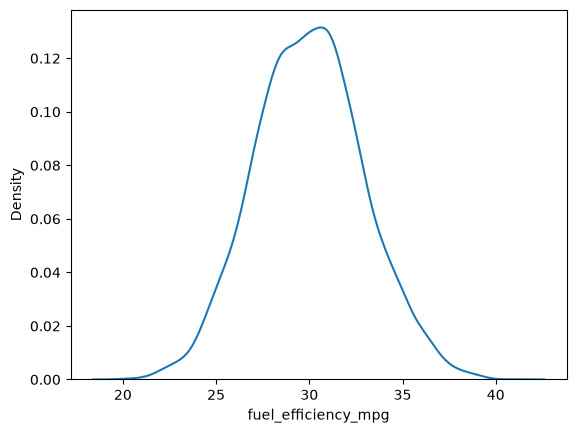

In [8]:
import seaborn as sns

sns.kdeplot(data=df_scoped, x="fuel_efficiency_mpg")

In [9]:
y = df_scoped["fuel_efficiency_mpg"]
X = df_scoped.drop(["fuel_efficiency_mpg"], axis=1)
print("y: ", y[:5])
print("X: ", X.head())

y:  0    31.9
1    31.3
2    27.5
3    28.5
4    31.0
Name: fuel_efficiency_mpg, dtype: float64
X:     engine_displacement  horsepower  vehicle_weight  model_year
0                 2180       243.0            3870        2006
1                 2390       272.0            4210        2008
2                 2320       267.0            4240        1996
3                 2130       258.0            4490        1989
4                 2580       304.0            4510        1994


In [10]:
X.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,10000.000000,9123.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500
std,183.447355,22.844613,266.212491,14.207925
min,1590.000000,171.000000,3320.000000,1975.000000
25%,2150.000000,239.000000,4110.000000,1987.000000
50%,2270.000000,254.000000,4280.000000,2000.000000
75%,2390.000000,270.000000,4470.000000,2012.000000
max,3110.000000,334.000000,5460.000000,2024.000000


In [13]:
X.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
dtype: int64

In [14]:
X['horsepower'].median()

np.float64(254.0)

In [15]:
import numpy as np

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [18]:
features = ['engine_displacement','horsepower','vehicle_weight','model_year']
label = 'fuel_efficiency_mpg'

In [19]:
X_train0 = df_train[features].copy()
y_train0 = df_train[label].copy()
X_train0['horsepower'] = df_train['horsepower'].fillna(0)
X_train0.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,2268.203333,231.646500,4283.440000,1999.473500
std,182.542577,75.856946,265.904025,14.263305
min,1590.000000,0.000000,3320.000000,1975.000000
25%,2150.000000,234.000000,4110.000000,1987.000000
50%,2270.000000,252.000000,4280.000000,1999.000000
75%,2390.000000,268.000000,4460.000000,2012.000000
max,3110.000000,334.000000,5460.000000,2024.000000


In [20]:
X_val0 = df_val[features].copy()
y_val0 = df_val[label].copy()
X_val0['horsepower'] = df_val['horsepower'].fillna(0)
X_val0.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,2000.000000,2000.000000,2000.000000,2000.00000
mean,2270.205000,231.996500,4290.575000,1999.53300
std,186.238155,75.442656,268.505991,14.07718
min,1700.000000,0.000000,3370.000000,1975.00000
25%,2150.000000,233.750000,4110.000000,1987.75000
50%,2270.000000,251.000000,4290.000000,2000.00000
75%,2400.000000,269.000000,4470.000000,2011.00000
max,2900.000000,332.000000,5200.000000,2024.00000


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

model = LinearRegression()
model.fit(X_train0, y_train0)
pred0 = model.predict(X_val0)
rmse0 = root_mean_squared_error(y_val0, pred0)
print(round(rmse0, 3))

2.205


In [24]:
X_train5 = df_train[features].copy()
median_hp = X_train5['horsepower'].median()
y_train5 = df_train[label].copy()
X_train5['horsepower'] = X_train5['horsepower'].fillna(median_hp)
X_train5.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,2268.203333,254.421833,4283.440000,1999.473500
std,182.542577,21.632419,265.904025,14.263305
min,1590.000000,171.000000,3320.000000,1975.000000
25%,2150.000000,241.000000,4110.000000,1987.000000
50%,2270.000000,254.000000,4280.000000,1999.000000
75%,2390.000000,268.000000,4460.000000,2012.000000
max,3110.000000,334.000000,5460.000000,2024.000000


In [25]:
X_val5 = df_val[features].copy()
y_val5 = df_val[label].copy()
X_val5['horsepower'] = X_val5['horsepower'].fillna(median_hp)
X_val5.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,2000.000000,2000.000000,2000.000000,2000.00000
mean,2270.205000,254.348500,4290.575000,1999.53300
std,186.238155,22.262544,268.505991,14.07718
min,1700.000000,181.000000,3370.000000,1975.00000
25%,2150.000000,240.000000,4110.000000,1987.75000
50%,2270.000000,254.000000,4290.000000,2000.00000
75%,2400.000000,269.000000,4470.000000,2011.00000
max,2900.000000,332.000000,5200.000000,2024.00000


In [26]:
model2 = LinearRegression()
model2.fit(X_train5, y_train5)
pred5 = model2.predict(X_val5)
rmse5 = root_mean_squared_error(y_val5, pred5)
print(round(rmse5, 3))

2.202


In [31]:
r = [0, 0.01, 0.1, 1, 5, 10, 100]
X_train_r = df_train[features].copy()
y_train_r = df_train[label].copy()
X_train_r['horsepower'] = X_train_r['horsepower'].fillna(0)
X_train_r.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,2268.203333,231.646500,4283.440000,1999.473500
std,182.542577,75.856946,265.904025,14.263305
min,1590.000000,0.000000,3320.000000,1975.000000
25%,2150.000000,234.000000,4110.000000,1987.000000
50%,2270.000000,252.000000,4280.000000,1999.000000
75%,2390.000000,268.000000,4460.000000,2012.000000
max,3110.000000,334.000000,5460.000000,2024.000000


In [32]:
X_val_r = df_val[features].copy()
y_val_r = df_val[label].copy()
X_val_r['horsepower'] = X_val_r['horsepower'].fillna(0)
X_val_r.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,2000.000000,2000.000000,2000.000000,2000.00000
mean,2270.205000,231.996500,4290.575000,1999.53300
std,186.238155,75.442656,268.505991,14.07718
min,1700.000000,0.000000,3370.000000,1975.00000
25%,2150.000000,233.750000,4110.000000,1987.75000
50%,2270.000000,251.000000,4290.000000,2000.00000
75%,2400.000000,269.000000,4470.000000,2011.00000
max,2900.000000,332.000000,5200.000000,2024.00000


In [35]:
from sklearn.linear_model import Ridge, Lasso

ridge_results = {}
lasso_results = {}

for r_i in r:
    ridge_model = Ridge(alpha=r_i)
    ridge_model.fit(X_train_r, y_train_r)
    pred_ridge = ridge_model.predict(X_val_r)
    rmse_ridge = root_mean_squared_error(y_val_r, pred_ridge)
    ridge_results[r_i] = round(rmse_ridge, 4)
    lasso_model = Lasso(alpha=r_i)
    lasso_model.fit(X_train_r, y_train_r)
    pred_lasso = lasso_model.predict(X_val_r)
    rmse_lasso = root_mean_squared_error(y_val_r, pred_lasso)
    lasso_results[r_i] = round(rmse_lasso, 4)

print("ridge results: ", ridge_results)
print("lasso_results: ", lasso_results)

ridge results:  {0: 2.2053, 0.01: 2.2053, 0.1: 2.2053, 1: 2.2053, 5: 2.2053, 10: 2.2053, 100: 2.2053}
lasso_results:  {0: 2.2053, 0.01: 2.2053, 0.1: 2.2052, 1: 2.2057, 5: 2.2291, 10: 2.306, 100: 2.6386}


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


In [36]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmses = []
for seed in seeds:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    X_train0 = df_train[features].copy()
    y_train0 = df_train[label].copy()
    X_train0['horsepower'] = df_train['horsepower'].fillna(0)
    X_val0 = df_val[features].copy()
    y_val0 = df_val[label].copy()
    X_val0['horsepower'] = df_val['horsepower'].fillna(0)
    model = LinearRegression()
    model.fit(X_train0, y_train0)
    pred0 = model.predict(X_val0)
    rmse0 = root_mean_squared_error(y_val0, pred0)
    rmses.append(rmse0)

print(round(np.std(np.asarray(rmses)), 3))

0.029


In [40]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
X_train0 = df_train[features].copy()
y_train0 = df_train[label].copy()
X_train0['horsepower'] = X_train0['horsepower'].fillna(0)
X_val0 = df_val[features].copy()
y_val0 = df_val[label].copy()
X_val0['horsepower'] = X_val0['horsepower'].fillna(0)
X_test = df_test[features].copy()
X_test['horsepower'] = X_test['horsepower'].fillna(0)
y_test = df_test[label].copy()
X_train = pd.concat([X_train0, X_val0], ignore_index=True)
y_train = pd.concat([y_train0, y_val0], ignore_index=True)

In [41]:
X_train.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,8000.000000,8000.000000,8000.000000,8000.000000
mean,2270.388750,232.688875,4289.748750,1999.517000
std,182.823041,74.738498,264.922484,14.198597
min,1590.000000,0.000000,3330.000000,1975.000000
25%,2150.000000,234.000000,4110.000000,1987.000000
50%,2270.000000,252.000000,4290.000000,2000.000000
75%,2390.000000,268.000000,4470.000000,2012.000000
max,3110.000000,334.000000,5460.000000,2024.000000


In [42]:
X_test.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,2262.480000,229.900000,4274.775000,1999.679500
std,185.835188,77.047869,271.047566,14.247992
min,1670.000000,0.000000,3320.000000,1975.000000
25%,2140.000000,232.000000,4090.000000,1987.000000
50%,2270.000000,251.000000,4270.000000,1999.000000
75%,2390.000000,268.000000,4460.000000,2012.000000
max,2900.000000,328.000000,5200.000000,2024.000000


In [43]:

model3 = Ridge(alpha=0.001)
model4 = Lasso(alpha=0.001)
model3.fit(X_train, y_train)
model4.fit(X_train, y_train)
pred3 = model3.predict(X_test)
pred4 = model4.predict(X_test)
rmse3 = root_mean_squared_error(y_test, pred3)
rmse4 = root_mean_squared_error(y_test, pred4)
print("rmse ridge: ", rmse3)
print("rmse lasso: ", rmse4)


rmse ridge:  2.235774702813794
rmse lasso:  2.2357753228055746
